# DUDe Contrastive Model Comparison (50 Epochs)

This notebook compares the performance of the three architectures that were trained using the **DUDe** dataset for contrastive learning.

**Note:** These models were trained with `task=davis` and `contrastive=True`. This means they used DUDe for the contrastive objective but were evaluated on the Davis benchmarks.

**Models:**
1. **Baseline** (`baseline_contrastive`)
2. **Residual** (`residual_contrastive`)
3. **Deep MLP** (`deep_contrastive`)

*(CrossAttention is excluded as it is currently re-training)*

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import os

# Set plotting style
sns.set_theme(style="whitegrid")

def load_history(run_id):
    path = f"best_models/{run_id}/history.json"
    if not os.path.exists(path):
        print(f"Warning: {path} not found.")
        return None
    with open(path, "r") as f:
        return json.load(f)

# Load histories (Contrastive Runs)
baseline_hist = load_history("baseline_contrastive")
residual_hist = load_history("residual_contrastive")
deep_hist = load_history("deep_contrastive")

# Check if loaded
print("Baseline loaded:", baseline_hist is not None)
print("Residual loaded:", residual_hist is not None)
print("Deep MLP loaded:", deep_hist is not None)

Baseline loaded: True
Residual loaded: True
Deep MLP loaded: True


## 1. Training Loss Comparison

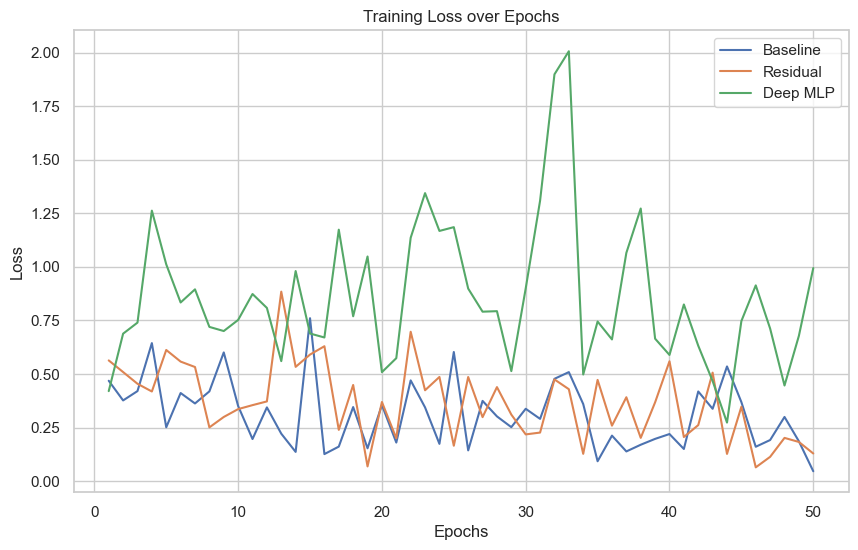

In [2]:
def plot_metric(histories, metric_key, title, ylabel):
    plt.figure(figsize=(10, 6))
    for name, hist in histories.items():
        if hist:
            data = hist[metric_key]
            epochs = range(1, len(data) + 1)
            sns.lineplot(x=epochs, y=data, label=name)
    
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

models = {
    "Baseline": baseline_hist,
    "Residual": residual_hist,
    "Deep MLP": deep_hist
}

plot_metric(models, "train_loss", "Training Loss over Epochs", "Loss")

## 2. Validation AUPR Comparison

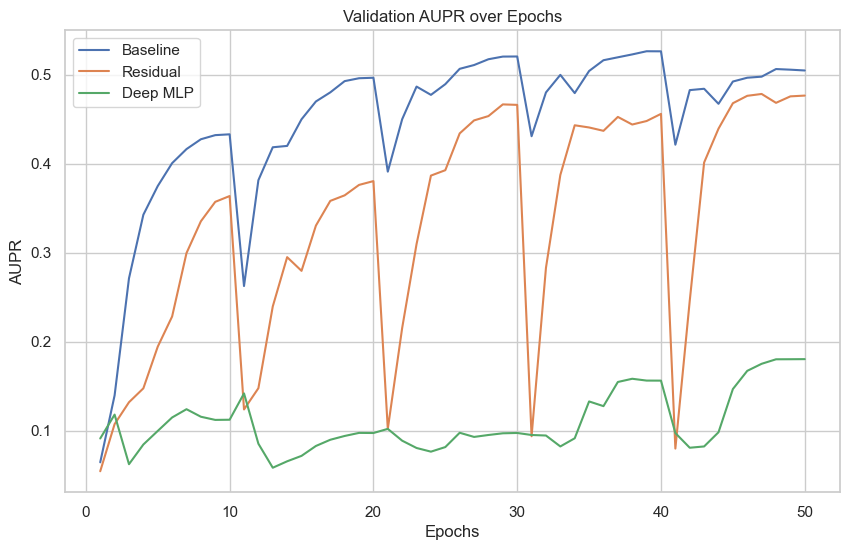

In [3]:
plot_metric(models, "val_aupr", "Validation AUPR over Epochs", "AUPR")

## 3. Final Test Performance Comparison

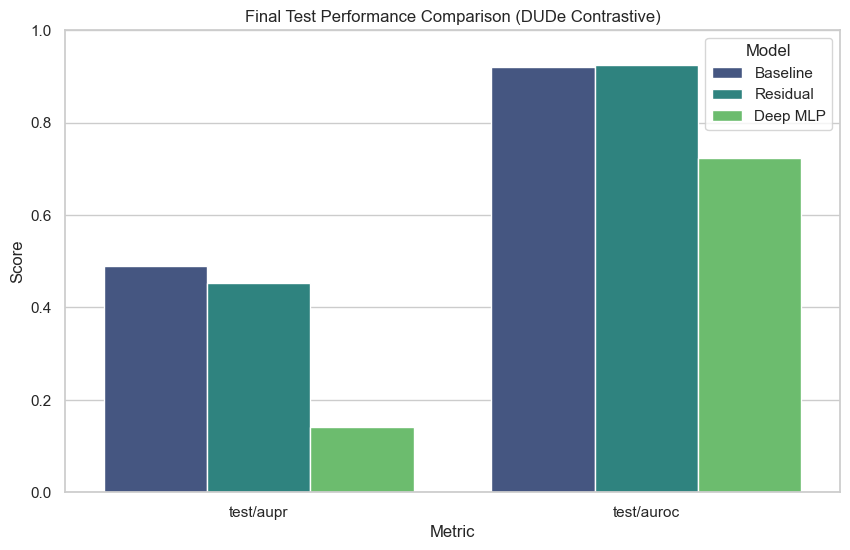

In [4]:
results = []
for name, hist in models.items():
    if hist and "test_results" in hist:
        res = hist["test_results"]
        res["Model"] = name
        # Ensure keys exist
        if "test/aupr" not in res: res["test/aupr"] = 0.0
        if "test/auroc" not in res: res["test/auroc"] = 0.0
        results.append(res)
    
df_res = pd.DataFrame(results)

# Melt for plotting
df_melt = df_res.melt(id_vars="Model", value_vars=["test/aupr", "test/auroc"], var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melt, x="Metric", y="Score", hue="Model", palette="viridis")
plt.title("Final Test Performance Comparison (DUDe Contrastive)")
plt.ylim(0, 1.0)
plt.show()

In [5]:
# Display exact values
df_res[["Model", "test/aupr", "test/auroc"]]

,Model,test/aupr,test/auroc
0,Baseline,0.489919,0.919435
1,Residual,0.454002,0.924604
2,Deep MLP,0.141686,0.723338
